# Existe relação entre o tipo de manifestação clínica inicial e o tempo até o diagnóstico?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re
from datetime import datetime
from datetime import date
from scipy.stats import chi2_contingency
import numpy as np
from dateutil.relativedelta import relativedelta
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import chi2_contingency, fisher_exact




# Importa os dados

In [3]:
df = pd.read_excel(
    "dados_atualizado.xlsx",
    sheet_name=0,
    header=1,          # usa a 2ª linha como cabeçalho real
    dtype={"Class. Por idade": str},  # evita converter "1" em número se quiser
)


## Criando Pipeline de Limpeza dos Dados

In [5]:
def limpa_dados(df):
    
    colunas_data = ["data_nascimento","data_primeira_consulta","data_primeira_colonoscopia"]

    def padroniza_colunas(df):
        df.columns = (df.columns.astype(str).str.replace("\n", " ", regex=False).str.replace(r"\s+", " ", regex=True).str.strip())
        return df

    def renomeia_colunas(df):
        df = df.rename(columns={
            "Nome": "nome",
            "Class. Por idade": "classificacao_idade",
            "Data nascimento": "data_nascimento",
            "Data 1ª consulta": "data_primeira_consulta",
            "Tempo entre início dos sintomas e primeira consulta": "intervalo_sintomas_primeira_consulta",
            "Sexo": "sexo",
            "Tipo": "tipo",
            "Perda de peso": "perda_peso",
            "Idade (meses) início dos sintomas": "intervalo_nascimento_sintomas",
            "Data 1ª colono": "data_primeira_colonoscopia",
            "Unnamed: 10": "intervalo_sintomas_primeira_colonoscopia",
            "Classificação": "diagnostico",
        })
        return df

    def formata_colunas_data(df):
        for coluna in colunas_data:
            df[coluna] = (pd.to_datetime(df[coluna], errors="coerce").dt.strftime("%d/%m/%Y"))
        return df

    def deixar_coluna_inteira(df, coluna):
        for index, tempo in enumerate(df[coluna].tolist()):
            if tempo != '?':
                numero = int(re.sub(r"\D", "", tempo))
                df.loc[index, coluna] = numero
            elif tempo == "?":
                df.loc[index, coluna] = -1
            df[coluna] = pd.to_numeric(df[coluna], errors="coerce")
            df[coluna] = df[coluna].astype("Int64")
        return df

        
    def criar_coluna(df, coluna):
        datas = pd.to_datetime(df['data_nascimento'],format="%d/%m/%Y",errors="coerce")
        meses = df["intervalo_nascimento_sintomas"]
        df[coluna] = [d + pd.DateOffset(months=int(m)) if pd.notna(d) and pd.notna(m) else pd.NaT for d, m in zip(datas, meses)  ]
        df[coluna] = (pd.to_datetime(df[coluna],errors="coerce" ).dt.strftime("%d/%m/%Y") )
        return df

    

    def ajustar_coluna_tipo(df):
        for index, tipo in enumerate(df['tipo'].tolist()):
            if tipo== 'Diarreia ':
                  df.loc[index, "tipo"] = 'Diarreia'
            
        return df
        
    def ajustar_coluna_classificacao_idade(df):
        for index, classificacao in enumerate(df['classificacao_idade'].tolist()):
            if classificacao== 'VEOIBD ':
                  df.loc[index, "classificacao_idade"] = 'VEOIBD'
            
        return df    
        
    def padronizar_sim_nao(df):
        for index, resposta in enumerate(df['perda_peso'].tolist()):
            if resposta == "não" or resposta == 'Não':
                  df.loc[index, "perda_peso"] = 'N'
            else:
                df.loc[index, "perda_peso"] = 'S'
        return df   


    def calcula_intervalo_colonoscopia(df):
        resultados = []
        for index in range(len(df)):
            d1_str = df.loc[index, "data_inicio_sintomas"]
            d2_str = df.loc[index, "data_primeira_colonoscopia"]
            # 1) converte para datetime
            try:
                d1 = datetime.strptime(d1_str, "%d/%m/%Y")
                d2 = datetime.strptime(d2_str, "%d/%m/%Y")
            except (ValueError, TypeError):
                resultados.append(None)
                continue
            # 2) valida ordem
            if d2 <= d1:
                resultados.append(None)
                continue
            # 3) calcula meses completos
            meses = ((d2.year - d1.year) * 12 + (d2.month - d1.month) - (d2.day < d1.day))

            resultados.append(meses)

        df["intervalo_sintomas_primeira_colonoscopia_recalculado"] = resultados
        df["intervalo_sintomas_primeira_colonoscopia_recalculado"] = pd.to_numeric(df["intervalo_sintomas_primeira_colonoscopia_recalculado"],errors="coerce")
        df["intervalo_sintomas_primeira_colonoscopia_recalculado"] = df["intervalo_sintomas_primeira_colonoscopia_recalculado"].astype("Int64")

        return df


    df = df.drop(index=0).reset_index(drop=True)
    df = padroniza_colunas(df)
    df = renomeia_colunas(df)
    df = formata_colunas_data(df)
    df = df.drop(columns=["nome"])
    df = deixar_coluna_inteira(df,"intervalo_sintomas_primeira_consulta")
    df = deixar_coluna_inteira(df,"intervalo_sintomas_primeira_colonoscopia")
    df = criar_coluna(df,"data_inicio_sintomas")  
    df = calcula_intervalo_colonoscopia(df)
    df = padronizar_sim_nao(df)
    df = ajustar_coluna_tipo(df)
    df = ajustar_coluna_classificacao_idade(df)

    return df

In [7]:
# Tipo =  Sintoma inicial
dados_df = limpa_dados(df)
dados_df = dados_df[dados_df["intervalo_sintomas_primeira_consulta"]!=-1]
dados_df = dados_df.drop(columns=['intervalo_sintomas_primeira_colonoscopia_recalculado'])
# Quebra o dataset
mulheres_df = dados_df[dados_df['sexo'] == 'F']

homens_df = dados_df[dados_df['sexo'] == 'M']


In [13]:
# dados_df

In [9]:
colunas_nao_categoricas = [
    "data_nascimento",
    "data_primeira_consulta",
    "intervalo_sintomas_primeira_consulta", 
    "intervalo_nascimento_sintomas", 
    "data_primeira_colonoscopia",  
    "intervalo_sintomas_primeira_colonoscopia",    
    "data_inicio_sintomas"]

dados_categoricos_df = dados_df.drop(columns=colunas_nao_categoricas)


mulheres_categoricos_df = mulheres_df.drop(columns=colunas_nao_categoricas)

homens_categoricos_df = homens_df.drop(columns=colunas_nao_categoricas)

In [63]:
# mulheres_categoricos_df


In [15]:
# Salvando o DataFrame em um arquivo CSV
dados_df.to_csv('dataset_limpo.csv', index=False)

# Obter alguns numeros referentes ao dataset geral

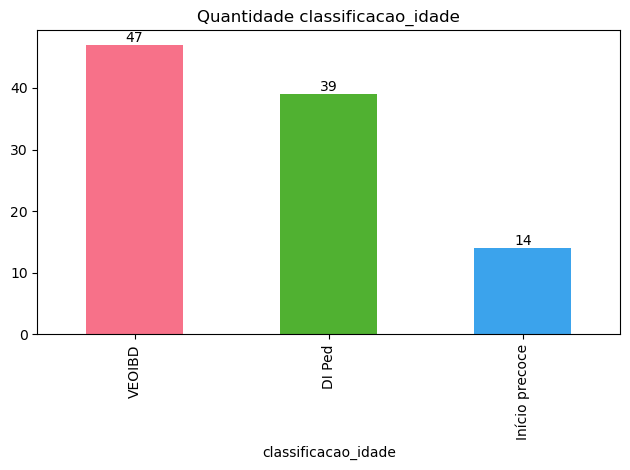

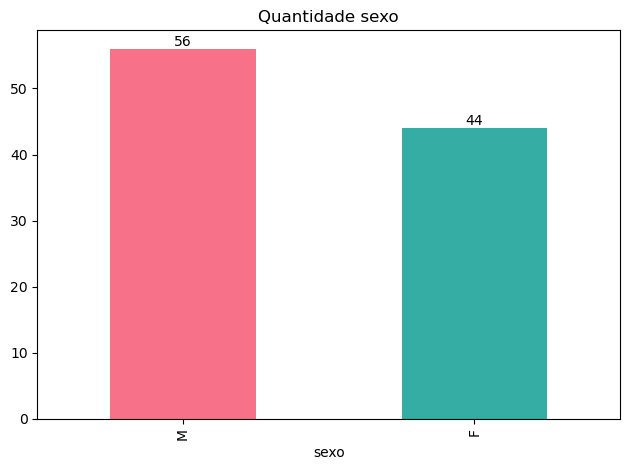

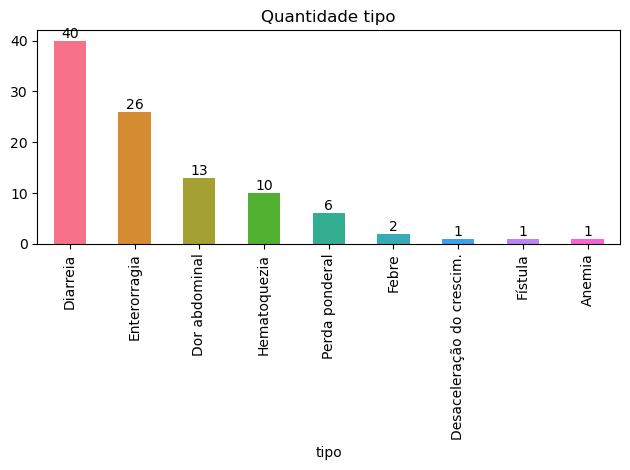

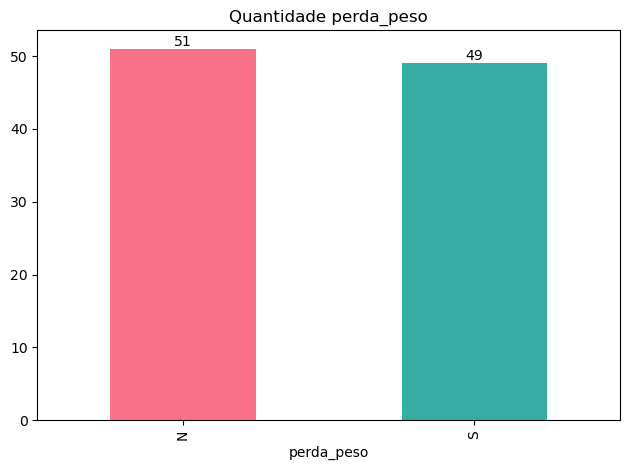

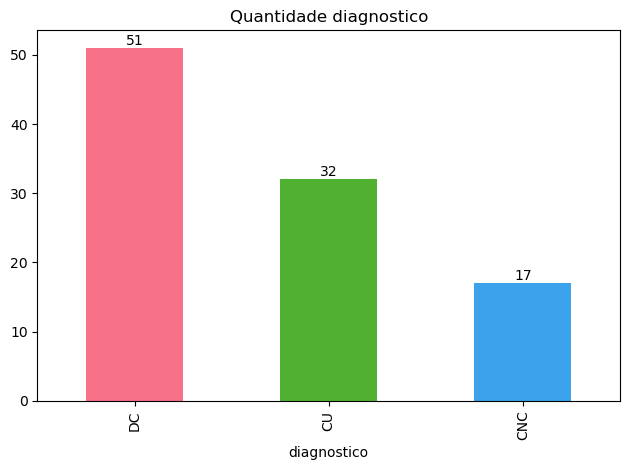

In [11]:
for categoria in dados_categoricos_df:
    # print(categoria)
    contagem = dados_df[categoria].value_counts()
    # print(contagem)
    cores = sns.color_palette("husl", len(contagem))
    ax = contagem.plot(kind="bar", color=cores)
    ax.set_title(f'Quantidade {categoria}')
    ax.set_xlabel(categoria)
    # ax.set_ylabel("Quantidade")  
    for container in ax.containers:
        ax.bar_label(container)
    # plt.xticks(rotation=0)
    # plt.tight_layout()
    # plt.show()  
    plt.tight_layout()
    plt.savefig(f"geral_{categoria}.png", dpi=300, bbox_inches="tight")
    plt.show()
    

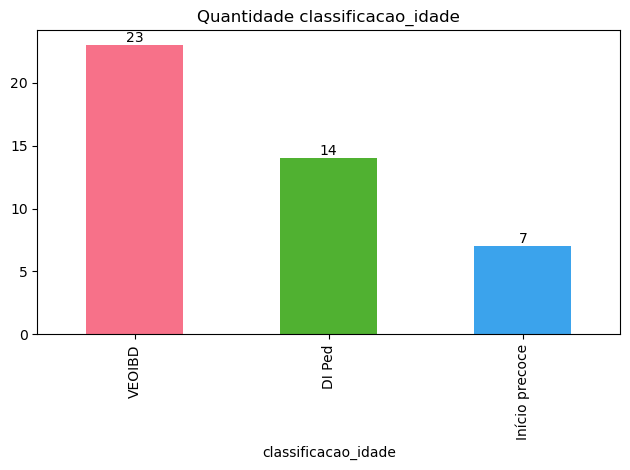

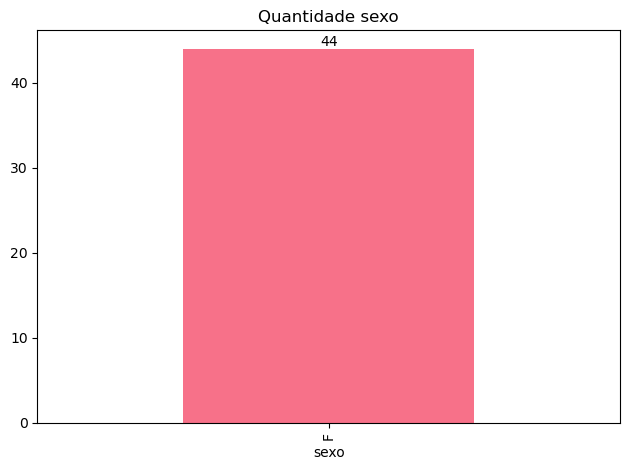

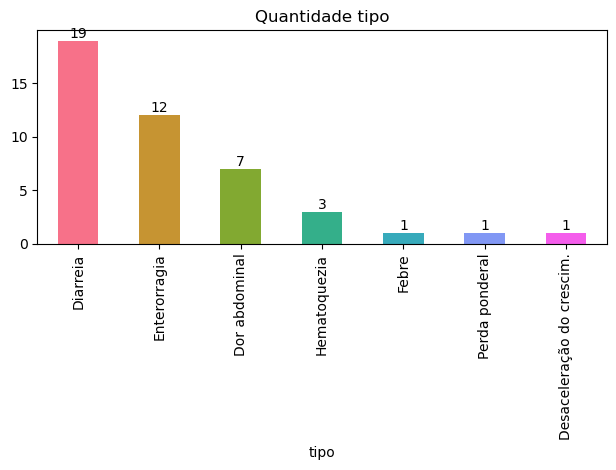

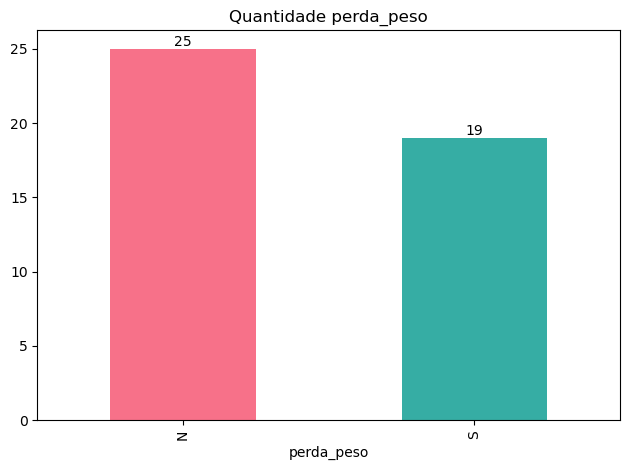

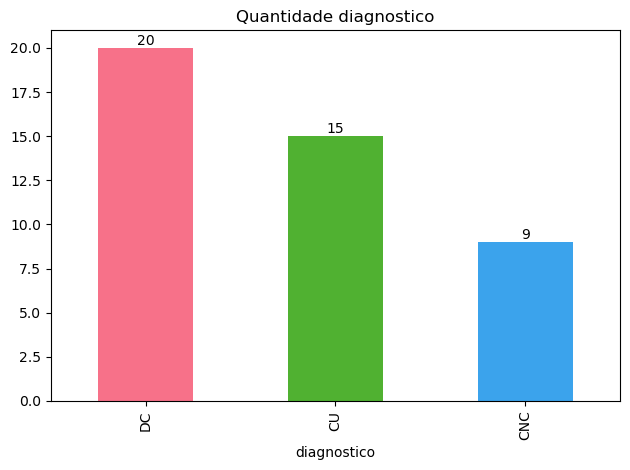

In [13]:
for categoria in mulheres_categoricos_df:
    # print(categoria)
    contagem = mulheres_categoricos_df[categoria].value_counts()
    # print(contagem)
    cores = sns.color_palette("husl", len(contagem))
    ax = contagem.plot(kind="bar", color=cores)
    ax.set_title(f'Quantidade {categoria}')
    ax.set_xlabel(categoria)
    # ax.set_ylabel("Quantidade")  
    for container in ax.containers:
        ax.bar_label(container)
    # plt.xticks(rotation=0)
    # plt.tight_layout()
    # plt.show()  
    plt.tight_layout()
    plt.savefig(f"mulheres_{categoria}.png", dpi=300, bbox_inches="tight")
    plt.show()

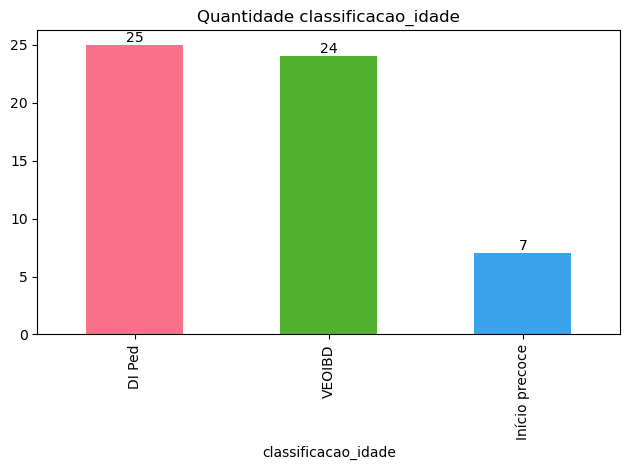

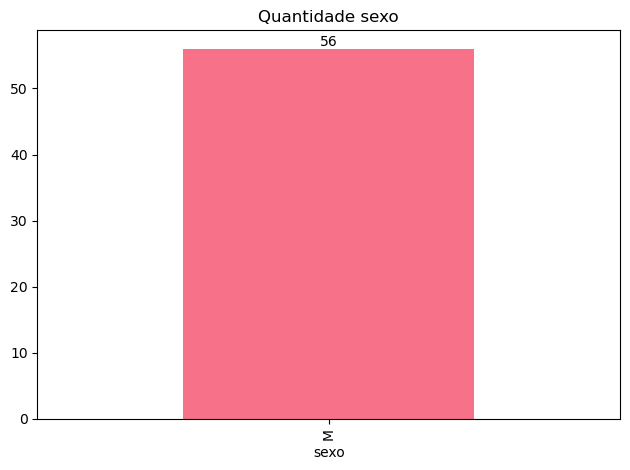

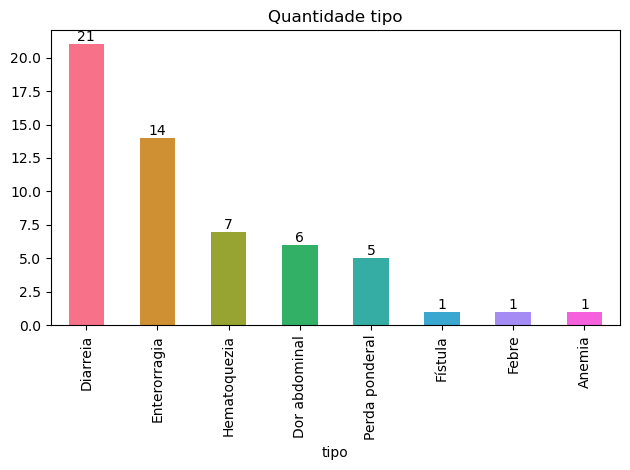

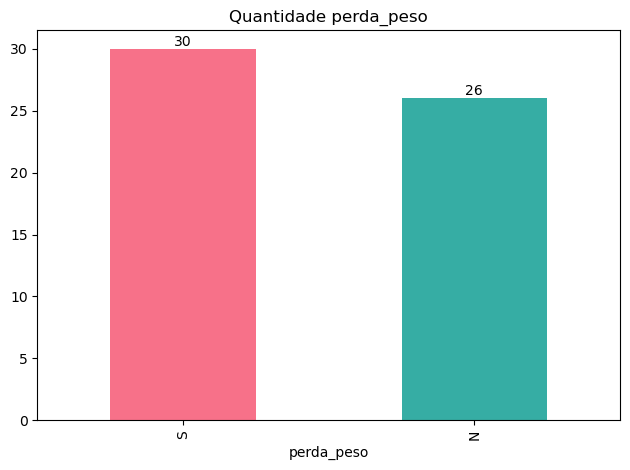

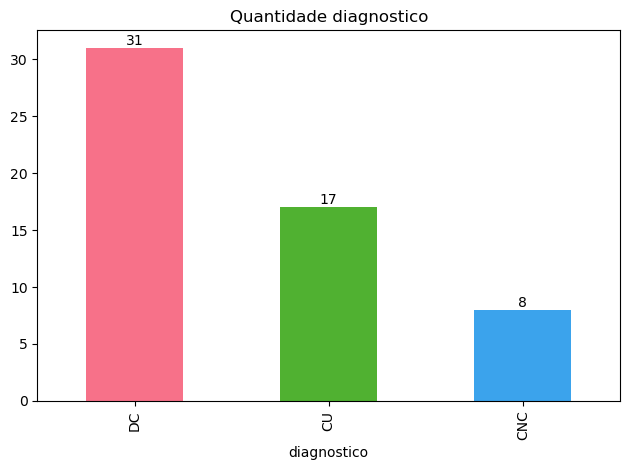

In [15]:
for categoria in homens_categoricos_df:
    # print(categoria)
    contagem = homens_categoricos_df[categoria].value_counts()
    # print(contagem)
    cores = sns.color_palette("husl", len(contagem))
    ax = contagem.plot(kind="bar", color=cores)
    ax.set_title(f'Quantidade {categoria}')
    ax.set_xlabel(categoria)
    # ax.set_ylabel("Quantidade")  
    for container in ax.containers:
        ax.bar_label(container)
    # plt.xticks(rotation=0)
    # plt.tight_layout()
    # plt.show()  
    plt.tight_layout()
    plt.savefig(f"homens_{categoria}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Analise Bivariada.

In [97]:
def create_table(categoria1, categoria2):
    # Observada SEM margens: é a que entra no teste
    obs = pd.crosstab(categoria1, categoria2)

    chi2, p, dof, esp = chi2_contingency(obs)
    esp = pd.DataFrame(esp, index=obs.index, columns=obs.columns)

    # Resíduos de Pearson (sem coluna/linha Total)
    resid = ((obs - esp) / np.sqrt(esp)).round(2)

    # Versões com margens, só para exibição
    obs_total = pd.crosstab(categoria1, categoria2, margins=True, margins_name="Total")
    esp_total = esp.copy()
    esp_total["Total"] = esp_total.sum(axis=1)
    esp_total.loc["Total"] = esp_total.sum()

    n = obs.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(obs.shape) - 1)))

    # --- Checagem do pressuposto (esperado < 5) ---
    pct_menor_5 = (esp < 5).values.mean() * 100
    esp_min = esp.values.min()
    pressuposto_ok = (pct_menor_5 <= 20) and (esp_min >= 1)

    teste_usado = "qui-quadrado"
    p_final = p
    aviso = ""

    if not pressuposto_ok:
        if obs.shape == (2, 2):
            _, p_final = fisher_exact(obs)
            teste_usado = "Fisher exato"
            aviso = "Esperado < 5: usado o teste exato de Fisher."
        else:
            teste_usado = "qui-quadrado (NÃO confiável)"
            aviso = "Esperado < 5 em tabela maior que 2x2: agrupe categorias raras."

    return {
        "observada": obs_total,
        "esperada": esp_total.round(2),
        "residuos": resid,
        "chi2": chi2,
        "p": p,
        "dof": dof,
        "cramers_v": cramers_v,
        "pct_esp_menor_5": pct_menor_5,
        "esp_min": esp_min,
        "pressuposto_ok": pressuposto_ok,
        "teste_usado": teste_usado,
        "p_final": p_final,
        "aviso": aviso,
    }

In [12]:
# Alpha 0,05 ou 5 %
# xcritico = chi2.ppf(0.95, df=1)
# xcritico

In [101]:
# sexo_diagnostico = create_table(dados_categoricos_df['sexo'],dados_categoricos_df['diagnostico'])
# sexo_diagnostico

# Analise de associacao das variaveis categoricas dados_df

In [99]:
alpha = 0.05

In [91]:
colunas_categoricas = dados_categoricos_df.columns.tolist()
n = len(colunas_categoricas)

resultados_manual = []

# colunas_categoricas

analise_bivariada = []

for i in range(n):
    for j in range(n):
        if i < j:
            col1 = colunas_categoricas[i]
            col2 = colunas_categoricas[j]
            # print(col1,col2)
            res = create_table(dados_categoricos_df[col1],dados_categoricos_df[col2])
            # print(f"χ² = {res['chi2']:.2f} | p = {res['p_final']:.3f} | gl = {res['dof']} | V = {res['cramers_v']:.2f}")
            if res["p_final"] < alpha:
                print(f"{col1} x {col2}")
                print(f"χ² = {res['chi2']:.2f} | p = {res['p_final']:.3f} | gl = {res['dof']} | V = {res['cramers_v']:.2f}")
                if res["aviso"]:
                    print("Atenção:", res["aviso"])
                print(res["residuos"])
                print()

classificacao_idade x tipo
χ² = 31.44 | p = 0.012 | gl = 16 | V = 0.40
Atenção: Esperado < 5 em tabela maior que 2x2: agrupe categorias raras.
tipo                 Anemia  Desaceleração do crescim.  Diarreia  \
classificacao_idade                                                
DI Ped                 0.98                      -0.62     -0.15   
Início precoce        -0.37                      -0.37      1.01   
VEOIBD                -0.69                       0.77     -0.42   

tipo                 Dor abdominal  Enterorragia  Febre  Fístula  \
classificacao_idade                                                
DI Ped                        2.19         -1.61   0.25     0.98   
Início precoce                0.13         -1.38   1.36    -0.37   
VEOIBD                       -2.07          2.23  -0.97    -0.69   

tipo                 Hematoquezia  Perda ponderal  
classificacao_idade                                
DI Ped                      -0.96            1.09  
Início precoce     

# Analise de associacao das variaveis categoricas MULHERES

In [105]:
colunas_categoricas = mulheres_categoricos_df.columns.tolist()
n = len(colunas_categoricas)

resultados_manual = []

# colunas_categoricas

analise_bivariada = []

for i in range(n):
    for j in range(n):
        if i < j:
            col1 = colunas_categoricas[i]
            col2 = colunas_categoricas[j]
            # print(col1,col2)
            res = create_table(mulheres_categoricos_df[col1],mulheres_categoricos_df[col2])
            # print(f"χ² = {res['chi2']:.2f} | p = {res['p_final']:.3f} | gl = {res['dof']} | V = {res['cramers_v']:.2f}")
            if res["p_final"] < alpha:
                print(f"{col1} x {col2}")
                print(f"χ² = {res['chi2']:.2f} | p = {res['p_final']:.3f} | gl = {res['dof']} | V = {res['cramers_v']:.2f}")
                if res["aviso"]:
                    print("Atenção:", res["aviso"])
                print(res["residuos"])
                print()

classificacao_idade x tipo
χ² = 21.79 | p = 0.040 | gl = 12 | V = 0.50
Atenção: Esperado < 5 em tabela maior que 2x2: agrupe categorias raras.
tipo                 Desaceleração do crescim.  Diarreia  Dor abdominal  \
classificacao_idade                                                       
DI Ped                                   -0.56      0.79           1.86   
Início precoce                           -0.40      0.56          -0.11   
VEOIBD                                    0.66     -0.93          -1.39   

tipo                 Enterorragia  Febre  Hematoquezia  Perda ponderal  
classificacao_idade                                                     
DI Ped                      -1.44  -0.56         -0.98           -0.56  
Início precoce              -0.66   2.11         -0.69           -0.40  
VEOIBD                       1.49  -0.72          1.14            0.66  



/var/folders/67/sty1wlj57gz5hq6p23frp3pc0000gn/T/ipykernel_15789/4108378483.py:18: RuntimeWarning: invalid value encountered in divide
  cramers_v = np.sqrt(chi2 / (n * (min(obs.shape) - 1)))
/var/folders/67/sty1wlj57gz5hq6p23frp3pc0000gn/T/ipykernel_15789/4108378483.py:18: RuntimeWarning: invalid value encountered in divide
  cramers_v = np.sqrt(chi2 / (n * (min(obs.shape) - 1)))
/var/folders/67/sty1wlj57gz5hq6p23frp3pc0000gn/T/ipykernel_15789/4108378483.py:18: RuntimeWarning: invalid value encountered in divide
  cramers_v = np.sqrt(chi2 / (n * (min(obs.shape) - 1)))
/var/folders/67/sty1wlj57gz5hq6p23frp3pc0000gn/T/ipykernel_15789/4108378483.py:18: RuntimeWarning: invalid value encountered in divide
  cramers_v = np.sqrt(chi2 / (n * (min(obs.shape) - 1)))


# Função que retorna as tabelas de contingencias para duas categorias

In [21]:
tabela_cont_diagnostico_sexo = create_table(dados_df["diagnostico"],
    dados_df["sexo"])

In [19]:
tabela_cont_diagnostico_sexo[0]

sexo,F,M,Total
diagnostico,,,
CNC,9,8,17
CU,15,17,32
DC,20,31,51
Total,44,56,100


In [20]:
# plotar_bivariada(analise_bivariada[2],'ókoko')

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import textwrap

PALETA = ['#2E5077', '#E8A54B', '#6FA88A', '#B85C6B', '#7B6FA8', '#4B8FA8',
          '#C4A35A', '#5B8C85', '#9B6B9E']  # até 9 cores distintas
COR_HEADER = '#2E5077'
COR_TOTAL_BG = '#F0EDE5'
COR_GRID = '#D9D9D9'

def plotar_com_tabela(tabela, titulo=None):
    plt.close('all')  # <- evita sobreposição de figuras/legendas de chamadas anteriores no loop
    
    dados_plot = tabela.drop(index='Total', errors='ignore').drop(columns='Total', errors='ignore')
    n_categorias = dados_plot.shape[1]
    cores = (PALETA * ((n_categorias // len(PALETA)) + 1))[:n_categorias]  # repete paleta se precisar
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.3, 1.3]})
    
    # --- Painel 1: tabela ---
    axes[0].axis('off')
    tabela_texto = tabela.reset_index()
    n_cols = len(tabela_texto.columns)
    
    # quebra nomes de coluna longos em múltiplas linhas
    largura_max_char = max(10, 40 // n_cols)  # menos colunas = pode ter linha mais larga
    colunas_wrap = ['\n'.join(textwrap.wrap(str(c), largura_max_char)) for c in tabela_texto.columns]
    
    larguras = []
    for col_original, col_wrap in zip(tabela_texto.columns, colunas_wrap):
        max_len_dado = tabela_texto[col_original].astype(str).map(len).max()
        max_len_header = max(len(linha) for linha in col_wrap.split('\n'))
        larguras.append(max(max_len_dado, max_len_header))
    total_largura = sum(larguras)
    col_widths = [l / total_largura for l in larguras]
    
    # fonte menor quando há muitas colunas
    fonte_tabela = 10 if n_cols <= 5 else (8 if n_cols <= 8 else 7)
    
    tab = axes[0].table(
        cellText=tabela_texto.values,
        colLabels=colunas_wrap,
        cellLoc='center',
        loc='center',
        colWidths=col_widths
    )
    tab.auto_set_font_size(False)
    tab.set_fontsize(fonte_tabela)
    tab.scale(1, 2.4 if n_cols > 5 else 2.0)  # linhas mais altas para caber o cabeçalho quebrado
    
    for (row, col), cell in tab.get_celld().items():
        cell.set_edgecolor(COR_GRID)
        if row == 0:
            cell.set_facecolor(COR_HEADER)
            cell.set_text_props(color='white', weight='bold')
            cell.set_height(cell.get_height() * 1.8)  # espaço extra pro texto quebrado
        elif tabela_texto.iloc[row-1, 0] == 'Total':
            cell.set_facecolor(COR_TOTAL_BG)
            cell.set_text_props(weight='bold', color=COR_HEADER)
        else:
            cell.set_facecolor('white' if row % 2 else '#FAFAFA')
    
    axes[0].set_title('Tabela de contingência', fontsize=13, weight='bold',
                       color=COR_HEADER, pad=20)
    
    # --- Painel 2: gráfico de barras agrupadas ---
    dados_plot.plot(kind='bar', ax=axes[1], color=cores,
                     edgecolor='white', linewidth=0.8, width=0.75)
    axes[1].set_title(titulo or '', fontsize=13, weight='bold', color=COR_HEADER, pad=12)
    axes[1].set_ylabel('N° de casos', fontsize=10)
    axes[1].set_xlabel(dados_plot.index.name, fontsize=10)
    axes[1].tick_params(axis='x', rotation=20)
    
    # legenda: fora do gráfico, fonte menor se tiver muitas categorias
    fonte_legenda = 9 if n_categorias <= 5 else 7
    axes[1].legend(title=dados_plot.columns.name, frameon=False,
                    bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=fonte_legenda)
    
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].grid(axis='y', color=COR_GRID, linewidth=0.6, alpha=0.6, zorder=0)
    axes[1].set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

# plotar_com_tabela(analise_bivariada[X], titulo='sexo X tipo')

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# paleta mais ampla, com cores bem distintas entre si (funciona pra 2, 3, 4+ categorias)
PALETA = ['#2E5077', '#E8A54B', '#6FA88A', '#B85C6B', '#7B6FA8', '#4B8FA8']
COR_HEADER = '#2E5077'
COR_TOTAL_BG = '#F0EDE5'
COR_GRID = '#D9D9D9'

def plotar_com_tabela(tabela, titulo=None):
    dados_plot = tabela.drop(index='Total', errors='ignore').drop(columns='Total', errors='ignore')
    
    n_categorias = dados_plot.shape[1]
    cores = PALETA[:n_categorias]  # pega só as cores necessárias, na ordem
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1.2, 1.3]})
    
    # --- Painel 1: tabela ---
    axes[0].axis('off')
    tabela_texto = tabela.reset_index()
    
    larguras = []
    for col in tabela_texto.columns:
        max_len = max(tabela_texto[col].astype(str).map(len).max(), len(str(col)))
        larguras.append(max_len)
    total_largura = sum(larguras)
    col_widths = [l / total_largura for l in larguras]
    
    tab = axes[0].table(
        cellText=tabela_texto.values,
        colLabels=tabela_texto.columns,
        cellLoc='center',
        loc='center',
        colWidths=col_widths
    )
    tab.auto_set_font_size(False)
    tab.set_fontsize(10)
    tab.scale(1, 2.0)
    
    for (row, col), cell in tab.get_celld().items():
        cell.set_edgecolor(COR_GRID)
        if row == 0:
            cell.set_facecolor(COR_HEADER)
            cell.set_text_props(color='white', weight='bold')
        elif tabela_texto.iloc[row-1, 0] == 'Total':
            cell.set_facecolor(COR_TOTAL_BG)
            cell.set_text_props(weight='bold', color=COR_HEADER)
        else:
            cell.set_facecolor('white' if row % 2 else '#FAFAFA')
    
    axes[0].set_title('Tabela de contingência', fontsize=13, weight='bold',
                       color=COR_HEADER, pad=20)
    
    # --- Painel 2: gráfico de barras agrupadas ---
    dados_plot.plot(kind='bar', ax=axes[1], color=cores,
                     edgecolor='white', linewidth=0.8, width=0.75)
    axes[1].set_title(titulo or '', fontsize=13, weight='bold', color=COR_HEADER)
    axes[1].set_ylabel('N° de casos', fontsize=10)
    axes[1].set_xlabel(dados_plot.index.name, fontsize=10)
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend(title=dados_plot.columns.name, frameon=False)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].grid(axis='y', color=COR_GRID, linewidth=0.6, alpha=0.6, zorder=0)
    axes[1].set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

# plotar_com_tabela(analise_bivariada[X], titulo='Perda de peso x Diagnóstico')

In [111]:
colunas_categoricas = dados_categoricos_df.columns.tolist()
n = len(colunas_categoricas)

resultados_manual = []

# colunas_categoricas

analise_bivariada = []

for i in range(n):
    for j in range(n):
        if i < j:
            col1 = colunas_categoricas[i]
            col2 = colunas_categoricas[j]
            
            col1_col2_tres_df = create_table(dados_categoricos_df[col1],dados_categoricos_df[col2])
          
         
            analise_bivariada.append(col1_col2_tres_df[0])
            plotar_com_tabela(col1_col2_tres_df[0],f'{col1} X {col2}')


KeyError: 0

In [119]:
# //*
colunas_categoricas_mulheres = mulheres_categoricos_df.columns.tolist()
n = len(colunas_categoricas_mulheres)

resultados_manual_teste = []

# colunas_categoricas

analise_bivariada_mulheres = []

for i in range(n):
    for j in range(n):
        # j = j + 1
        if i < j:
            col1 = colunas_categoricas_mulheres[i]
            col2 = colunas_categoricas_mulheres[j]
            
            col1_col2_tres_df = create_table(mulheres_categoricos_df[col1],mulheres_categoricos_df[col2])
          
         
            analise_bivariada.append(col1_col2_tres_df[0])
            plotar_com_tabela(col1_col2_tres_df[0],f'{col1} X {col2}')

# //*

/var/folders/67/sty1wlj57gz5hq6p23frp3pc0000gn/T/ipykernel_14721/476329228.py:22: RuntimeWarning: invalid value encountered in divide
  cramers_v = np.sqrt(chi2 / (n * (min(obs.shape) - 1)))


KeyError: 0

In [25]:
# len(resultados_manual)
for i in :
    print(i)

SyntaxError: invalid syntax (3768416949.py, line 2)

In [ ]:
# Analise de associacao entre : SEXO X DIAGNOSTICO
tabela_sexo_diagnostico = pd.crosstab(
    dados_categoricos_df["diagnostico"],
    dados_categoricos_df["sexo"],
    margins=True,
    margins_name='Total'
)
tabela_sexo_diagnostico

In [ ]:
# Construindo a tabela com os valores esperados

# Eij = (Total linha i) x (Total coluna j) / Total Geral (44)


# Chi-quadrado → devolve esperados
chi2, p, dof, esp = chi2_contingency(tabela_sexo_diagnostico)

# Converte esperados em DataFrame com mesmos índices/colunas
tabela_esperada_s_d_df = pd.DataFrame(esp, index=tabela_sexo_diagnostico.index, columns=tabela_sexo_diagnostico.columns)

tabela_esperada_s_d_df.round(2)

In [ ]:
# Resíduos padronizados ajustados (Pearson)
resid_s_d = (tabela_sexo_diagnostico - tabela_esperada_s_d_df) / np.sqrt(tabela_esperada_s_d_df)
resid_s_d = resid_s_d.drop(columns=["Total"])
resid_s_d = resid_s_d[:-1]
resid_s_d.round(2)

In [ ]:
## Criar uma funcao que me retorna 3 df`s
# OSS

teste = create_table(dados_df["diagnostico"],
    dados_df["sexo"])
# for i in teste : 
#     print(i)


# Criacao da  CONSTANTE colunas_nao_categoricas

In [ ]:
# colunas_nao_categoricas = [
#     "data_nascimento",
#     "data_primeira_consulta",
#     "intervalo_sintomas_primeira_consulta", 
#     "intervalo_nascimento_sintomas", 
#     "data_primeira_colonoscopia",  
#     "intervalo_sintomas_primeira_colonoscopia",    
#     "data_inicio_sintomas",    
#     "intervalo_sintomas_primeira_colonoscopia_recalculado"
# ]

In [ ]:
# mulheres_df.head()
# mulheres_df[['data_nascimento','intervalo_nascimento_sintomas','data_inicio_sintomas']].head()

# Algumas estatisticas descritivas sobre a coluna intervalo_nascimento_sintomas

In [ ]:
round(pd.Series(mulheres_df["intervalo_nascimento_sintomas"].tolist()).describe(),2)

# Algumas estatisticas descritivas sobre a coluna intervalo_sintomas_primeira_colonoscopia

In [ ]:
round(pd.Series(mulheres_df["intervalo_sintomas_primeira_colonoscopia"].tolist()).describe(),2)

In [ ]:
mulheres_colunas_categoricas_df = mulheres_df.drop(columns=colunas_nao_categoricas)
mulheres_colunas_categoricas_df

In [ ]:
# classificacao_idade  = ['VEOIBD ', 'VEOIBD', 'DI Ped', 'Início precoce']

# tipo  = [
# 'Enterorragia',
# 'Dor abdominal',
# 'Diarreia',
# 'Febre',
# 'Perda ponderal',
# 'Hematoquezia', 
# 'Desaceleração do crescim.'
# ]


# perda_peso = ['N','S'] # Virou S ou N

# classificacao = ['CU', 'CNC', 'DC']

In [ ]:
# A mesma coisa porem de jeitos diferentes

# mulheres_df[(mulheres_df['tipo']=='Diarreia') & (mulheres_df['perda_peso'] == 'S')]

pd.crosstab(
    mulheres_colunas_categoricas_df["classificacao"],
    mulheres_colunas_categoricas_df["classificacao_idade"],
    margins=True,
    margins_name='Total'
)

In [ ]:
# resultado = df[(df['idade'] > 30) & (df['cidade'] == 'São Paulo')]
tabela_idade = pd.crosstab(
    mulheres_colunas_categoricas_df['classificacao_idade'],
    mulheres_colunas_categoricas_df['classificacao'],
    margins=True,
    margins_name='Total'
)
tabela_idade

In [ ]:
tabela_observada = pd.crosstab(mulheres_colunas_categoricas_df['tipo'], mulheres_colunas_categoricas_df['classificacao'], margins=True)
tabela_observada

In [ ]:
# Configuração para deixar o gráfico maior e mais legível
plt.figure(figsize=(12, 6))

# Criar o gráfico de barras
# 'hue' cria as cores separadas por tipo
ax = sns.countplot(data= mulheres_colunas_categoricas_df, 
                   x='classificacao', 
                   hue='tipo', 
                   palette='viridis')

# Adicionar os números em cima das barras (opcional, mas ajuda muito)
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribuição de Classificação por Tipo', fontsize=16)
plt.xlabel('Classificação', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks(rotation=45) # Rotaciona os nomes se forem grandes
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

In [ ]:
# Construindo a tabela com os valores esperados

# Eij = (Total linha i) x (Total coluna j) / Total Geral (44)


# Chi-quadrado → devolve esperados
chi2, p, dof, esp = chi2_contingency(tabela_observada)

# Converte esperados em DataFrame com mesmos índices/colunas
esp_df = pd.DataFrame(esp, index=tabela_observada.index, columns=tabela_observada.columns)

esp_df.round(2)

In [ ]:
# tab = pd.crosstab(mulheres_colunas_categoricas_df['tipo'], mulheres_colunas_categoricas_df['classificacao'])
chi2, p, dof, tabela_esp = chi2_contingency(tabela_observada)

# Rij = (Oij - Eij) / sqrt(Eij)

# Resíduos padronizados ajustados (Pearson)
resid = (tabela_observada - tabela_esp) / np.sqrt(tabela_esp)
resid = resid.drop(columns=["All"])
resid = resid[:-1]
resid.round(2)

In [ ]:
# clafissicacao_idade x diagnostico


In [ ]:
# Trazer mais graficos testes 

In [ ]:

print(f"χ² = {chi2:.2f}")
print(f"gl = {dof}")
print(f"p  = {p:.4f}")

In [ ]:
 # Regra de decisão:
# ∣r∣ ≥ 1,96 => significativo (p < 0,05)
# O resíduo padronizado de Pearson segue,
# aproximadamente, uma distribuição normal padrão (média 0, desvio padrão 1):
# se isso é verdade, então podemos usar a tabela da normal padrão (ou a função de distribuição acumulada) 
# para decidir se um valor de r é "grande demais" para ser fruto do acaso.

In [ ]:
cenarios = (
    mulheres_colunas_categoricas_df
    .groupby([
        "classificacao_idade",
        "tipo",
        "perda_peso",
        "classificacao"
    ])
    .size()
    .reset_index(name="quantidade")
    .sort_values("quantidade", ascending=False)
)

# cenarios

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=mulheres_colunas_categoricas_df,
    x="tipo",
    hue="classificacao"
)

plt.xticks(rotation=45)
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.title("Classificação por tipo")
plt.tight_layout()

plt.show()

In [ ]:
ct = pd.crosstab(
    [
        mulheres_colunas_categoricas_df["classificacao_idade"],
        mulheres_colunas_categoricas_df["tipo"],
        mulheres_colunas_categoricas_df["perda_peso"]
    ],
    mulheres_colunas_categoricas_df["classificacao"]
)

ct

In [ ]:
cenario = ct.loc[
    ("DI Ped", slice(None), "S"),
    :
]

cenario.index = cenario.index.droplevel([0, 2])

plt.figure(figsize=(8, 5))

sns.heatmap(
    cenario,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("DI Ped — Perda de peso: S")
plt.xlabel("Classificação")
plt.ylabel("Tipo")

plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(
    [
        mulheres_colunas_categoricas_df["classificacao_idade"],
        mulheres_colunas_categoricas_df["tipo"],
        mulheres_colunas_categoricas_df["perda_peso"]
    ],
    mulheres_colunas_categoricas_df["classificacao"]
)

In [ ]:
mulheres_colunas_categoricas_df[mulheres_colunas_categoricas_df['perda_peso'] == 'S']

## Analise Mulheres

## Analise Homens

In [ ]:
# homens_df
media2 = homens_df["intervalo_nascimento_sintomas"].mean()
media2